# NumPy

## Vectorisation

La transformation s'applique sur le tableau (`array`) entier, pas sur chaque élément individuellement.

In [3]:
import numpy as np

# Création d'un tableau NumPy
tableau_de_0_a_9 = np.array(range(10))
tableau_de_0_a_9 + 1  # On ajoute 1 à chaque élément du tableau par broadcasting

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

## Application d'une transformation sur un tableau NumPy
Peut se faire avec une fonction classique ou une fonction lambda
### Fonction classique

In [4]:
def is_prime(n: int) -> bool:
    """Retourne True si n est un nombre premier, False sinon."""
    if n < 2:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True


# Vectorisation de la fonction is_prime
is_prime_vectorized = np.vectorize(is_prime)
# Application de la fonction vectorisée sur le tableau
is_prime_vectorized(tableau_de_0_a_9)

array([False, False,  True,  True, False,  True, False,  True, False,
       False])

#### Fonction lambda

In [5]:
cube = lambda x: x ** 3
# Vectorisation de la fonction cube
cube_vectorized = np.vectorize(cube)
# Application de la fonction vectorisée sur le tableau
cube_vectorized(tableau_de_0_a_9)

array([  0,   1,   8,  27,  64, 125, 216, 343, 512, 729])

# Indexation et slicing

Les tableaux NumPy sont indexés de la même manière que les listes Python, mais ils offrent des fonctionnalités supplémentaires pour le slicing et l'indexation avancée.

In [6]:
# Le premier élément du tableau
print("Le premier élément du tableau ", tableau_de_0_a_9[0])
# Le dernier élément du tableau
print("Le dernier élément du tableau ", tableau_de_0_a_9[-1])
# Un sous-tableau avec les 3 premiers éléments
print("Les 3 premiers éléments du tableau ", tableau_de_0_a_9[0:3])
# ou
print("Les 3 premiers éléments du tableau ", tableau_de_0_a_9[:3])
# Indexation booléenne
print("Les éléments pairs du tableau ", tableau_de_0_a_9[tableau_de_0_a_9 % 2 == 0])
# Indexation avec une liste d'indices
indices = [0, 2, 4, 6, 8]
print("Les éléments aux indices ", indices, " du tableau ", tableau_de_0_a_9[indices])
# Indexation avec une liste de booléens appelée masque booléen
bool_mask = [True, False, True, False, True, False, True, False, True, False]
print("Les éléments du tableau avec la masque booléen ", bool_mask, " sont ", tableau_de_0_a_9[bool_mask])

Le premier élément du tableau  0
Le dernier élément du tableau  9
Les 3 premiers éléments du tableau  [0 1 2]
Les 3 premiers éléments du tableau  [0 1 2]
Les éléments pairs du tableau  [0 2 4 6 8]
Les éléments aux indices  [0, 2, 4, 6, 8]  du tableau  [0 2 4 6 8]
Les éléments du tableau avec la masque booléen  [True, False, True, False, True, False, True, False, True, False]  sont  [0 2 4 6 8]


## Les fonctions d'agrégations

Les fonctions d'agrégations sont utilisées pour réduire un tableau à une seule valeur en appliquant une fonction comme la somme, la médiane, moyenne, *etc*.

In [9]:
print("La somme des éléments du tableau ", tableau_de_0_a_9.sum())
print("La moyenne des éléments du tableau ", tableau_de_0_a_9.mean())
print("La médiane des éléments du tableau ", np.median(tableau_de_0_a_9))
print("Le maximum des éléments du tableau ", tableau_de_0_a_9.max())

La somme des éléments du tableau  20
La moyenne des éléments du tableau  4.5
La médiane des éléments du tableau  4.5
Le maximum des éléments du tableau  9


## Exercice

### Étude des températures à Bern

Avec toutes les mesures de température de l'année 2025 à Bern, présente dans le fichier `2025-06-06-ittigen papiermühle kreisel-2025.csv`, trouver la température moyenne, la température maximale et la température minimale.

In [24]:
!head -1 "2025-06-06-ittigen papiermühle kreisel-2025.csv"
from csv import DictReader
import numpy as np

with open("2025-06-06-ittigen papiermühle kreisel-2025.csv", "r") as file:
    reader = DictReader(file)
    temperatures = [float(row["temperature"]) for row in reader]
    temperatures_array = np.array(temperatures)
temperatures_array
print("La température moyenne à Bern est de ", round(temperatures_array.mean(), 2), "°C")
print("La température maximale à Bern est de ", round(temperatures_array.max(), 2), "°C")
print("La température minimale à Bern est de ", round(temperatures_array.min(), 2), "°C")

dateObserved,temperature,relativeHumidity
La température moyenne à Bern est de  11.12 °C
La température maximale à Bern est de  32.41 °C
La température minimale à Bern est de  -3.8 °C


### Étude de la végétalisation de Bern

Une image, comme une image satellite, peut être convertie en tableau NumPy avec la libraire `pillow`. C'est un tableau à trois dimensions où la première est un pixel et la seconde est la valeur de chaque canal de couleur RGB (rouge, vert, bleu) donc un tableau de 3 de long. Sachant qu'un pixel vert, assimilé à une surface végétale, peut être considéré comme de valeur comprise entre 100 et 255 pour le canal vert, et de valeur inférieure à 100 pour les canaux rouge et bleu, écrire le code qui permet de calculer le pourcentage d'espace végétalisé à Bern depuis l'image satellite `satellite-bern.png`.
Vérifier l'extraction des pixels verts en reconstituant uniquement avec ces derniers pixels (**Indice**: Il est plus simple d'utiliser la fonction `np.zeros_like` voir https://numpy.org/doc/2.2/reference/generated/numpy.zeros_like.html.

Percentage de surface végétale :  46.0 %


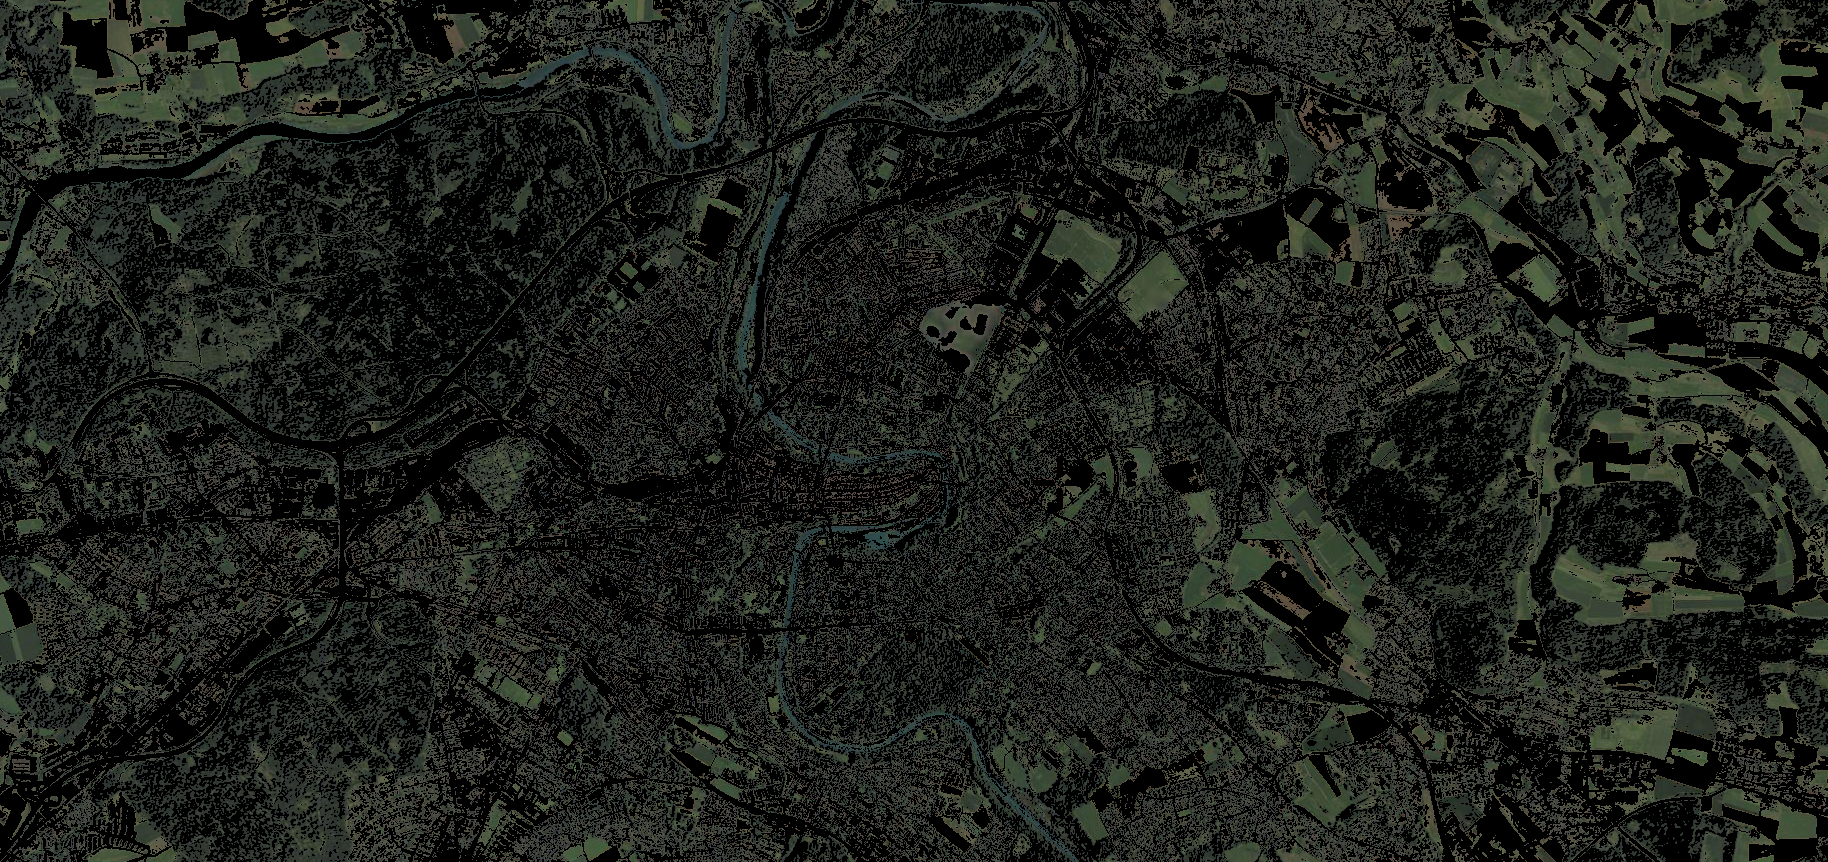

In [39]:
import numpy as np
from PIL import Image  # Pour manipuler les images

# Charger l'image
bern = Image.open('satellite-bern.png').convert('RGB')
img_array = np.array(bern)

# Extraire les canaux
R = img_array[:, :, 0]  # sélectionne toutes les lignes (:), toutes les colonnes (:) et le canal rouge (0)
G = img_array[:, :, 1]  # sélectionne toutes les lignes (:), toutes les colonnes (:) et le canal vert (1)
B = img_array[:, :, 2]  # sélectionne toutes les lignes (:), toutes les colonnes (:) et le canal bleu (2)

# Mask à peut prêt vert...
mask = ((G >= 50) & (B < 80) & (R < 100))

# Array des indices des pixels verts
green_array = img_array[mask]

# Avec shape faire la proportion de pixels verts
print("Percentage de surface végétale : ", round(green_array.size / img_array.size, 2) * 100, "%")

# Initialisation d'un array similaire à l'image d'origine mais avec les pixels verts
green_array_pic = np.zeros_like(img_array)

# Remplir l'array avec les pixels verts
green_array_pic[mask] = img_array[mask]

# Écrire l'image avec les pixels verts pour débug
bern_veg = Image.fromarray(green_array_pic)

# Display l'image
bern_veg